Total images: 10500
Total labels: 10500


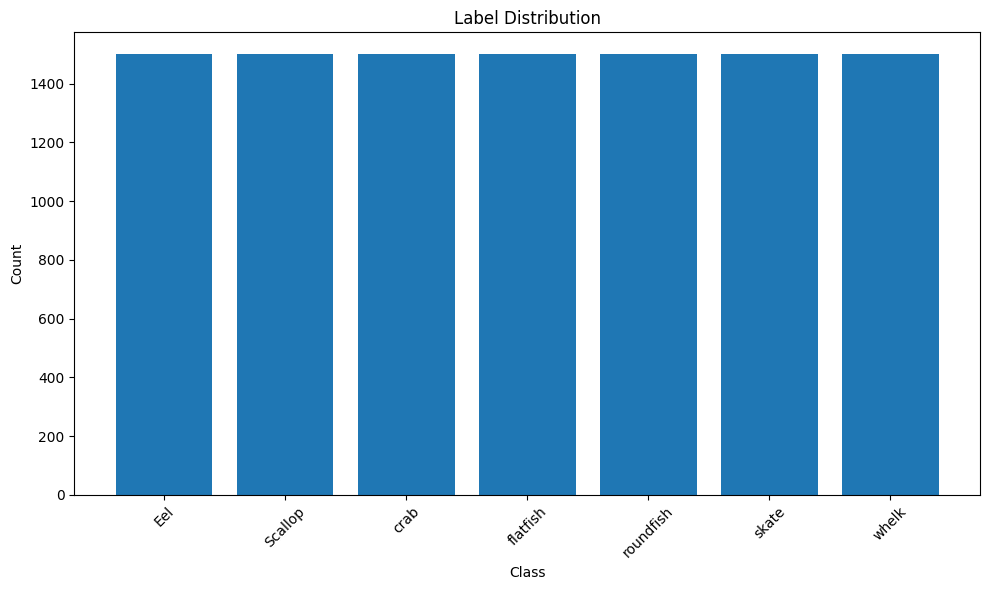

In [1]:
# Load dataset cell
# Mount Google Drive
# from google.colab import drive # UNCOMMENT THIS IF USING COLAB
import os
from PIL import Image
import numpy as np
# NOTE: I'm using my school's HPC, so I don't need to mount Google Drive. You can uncomment the above lines if you're using Google Colab.

# drive.mount('/content/drive')

# Set dataset path Use your own PATH!!
# dataset_path = '/scratch/jjung43/OceanicAI_Dataset/data/classification_dataset'
dataset_path = '/scratch/dfrom001/classification_dataset'
# dataset_path = '/content/drive/MyDrive/CV-Classification/classification_dataset'



# Load labels
labels_file = f'{dataset_path}/labels.txt'
image_names = []
labels = []

with open(labels_file, 'r') as f:
    for line in f.readlines():
        parts = line.strip().split()
        image_names.append(parts[0])
        labels.append(parts[1])

# Load image paths
image_folder = f'{dataset_path}/images'
image_paths = [os.path.join(image_folder, name) for name in image_names]

print(f"Total images: {len(image_paths)}")
print(f"Total labels: {len(labels)}")

# Display label distribution
import matplotlib.pyplot as plt
from collections import Counter

label_counts = Counter(labels)

plt.figure(figsize=(10, 6))
plt.bar(label_counts.keys(), label_counts.values())
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Label Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [5]:
# TODO: Build dataset with transform
# Hint: transforms.Resize, transforms.ToTensor, transforms.Normalize
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# I composed the transforms to be in line with standard resnet input
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class ImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.unique_labels = sorted(list(set(labels)))
        self.label_to_idx = {label: idx for idx, label in enumerate(self.unique_labels)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.label_to_idx[self.labels[idx]]
        if self.transform:
            image = self.transform(image)
        return image, label

dataset = ImageDataset(image_paths, labels, transform=transform)
print(f"Dataset size: {len(dataset)}")
print(f"Classes: {dataset.unique_labels}")
print(f"Label to index: {dataset.label_to_idx}")

Dataset size: 10500
Classes: ['Eel', 'Scallop', 'crab', 'flatfish', 'roundfish', 'skate', 'whelk']
Label to index: {'Eel': 0, 'Scallop': 1, 'crab': 2, 'flatfish': 3, 'roundfish': 4, 'skate': 5, 'whelk': 6}


# **Split Dataset**
0.8 training, 0.1 validation, 0.1 testing

Reasoning:
We'll use 0.8 for training because we aren't augmenting our data yet. We can consider switching to 0.75 training and 0.15 validation if we want to use data augmentation.

In [9]:
# TODO: Split dataset and create DataLoaders
# Hint: use torch.utils.data.random_split
# Hint: DataLoader needs batch_size and shuffle
from torch.utils.data import random_split, DataLoader
import torch

# Set random seed for reproducibility
seed = 42
torch.manual_seed(seed)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=6, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True, num_workers=6, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=6, pin_memory=True)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train size: 8400
Val size: 1050
Test size: 1050
Train batches: 263
Val batches: 33
Test batches: 33


In [10]:
# TODO: Define the model (Done)
# Hint: torchvision.models has many pretrained models to choose from
# Hint: don't forget to modify the final layer to match number of classes
import torch
import torch.nn as nn
from torchvision import models

num_classes = len(dataset.unique_labels)

# Option 1: ResNet18 (lightweight, good for small datasets)
# Hint: pretrained weights can be loaded with weights=models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Hint: the final layer is model.fc, replace it with a new Linear layer
model.fc = nn.Linear(model.fc.in_features, num_classes)


# TODO: Move model to GPU if available (Done)
# Hint: use torch.device and model.to(device)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Using device: {device}")
print(f"Number of classes: {num_classes}")
print(f"Model: {model.__class__.__name__}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/dfrom001/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 86.3MB/s]


Using device: cpu
Number of classes: 7
Model: ResNet


In [11]:
# TODO: Define loss function (Done)
# Hint: CrossEntropyLoss is standard for multi-class classification
# Hint: for class imbalance, use weight parameter in CrossEntropyLoss
criterion = torch.nn.CrossEntropyLoss()


# TODO: Define optimizer (Done)
# Hint: lr (learning rate) controls how big each update step is
# Hint: too high = unstable training, too low = slow convergence

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# TODO: Define learning rate scheduler (Done)
# Hint: scheduler adjusts learning rate during training
# Option 1: StepLR (reduce lr by gamma every step_size epochs)
# Hint: gamma=0.1 means lr is multiplied by 0.1 every step_size epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# TODO: Define the epoch number of training (Done)
num_epochs = 40

print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Scheduler: {scheduler.__class__.__name__}")
print(f"Number of epochs: {num_epochs}")

Optimizer: Adam
Learning rate: 0.001
Scheduler: StepLR
Number of epochs: 40


In [12]:
# TODO: Write the training loop
# Hint: each epoch consists of a training phase and a validation phase
# Hint: don't forget to switch between model.train() and model.eval()

# ============ Early stopping and checkpointing parameters ============
# best_val_acc = 0.0 <-- initialize best validation accuracy to 0, but I think we should be checking for val_loss?
best_val_loss = float('inf')     # Initialize best validation loss to infinity
patience = 20                     # Number of epochs to wait for improvement before stopping
epochs_no_improve = 0
checkpoint_dir = 'model_checkpoints' # Path to save the best model checkpoint
save_path = os.path.join(checkpoint_dir, 'best_resnet18.pth')
os.makedirs(checkpoint_dir, exist_ok=True)
# ======================================================================
from tqdm import tqdm

for epoch in range(num_epochs):

    # Training phase
    # model.train() enables dropout and batch normalization
    model.train()
    train_loss = 0.0
    train_correct = 0

    # Hint: wrap dataloader with tqdm to show progress bar
    train_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train")
    for images, labels in train_bar:

        images, labels = images.to(device), labels.to(device) #  move data to device
        optimizer.zero_grad() # zero the gradients before each batch

        # ================ forward pass ================
        outputs = model(images)
        loss = criterion(outputs, labels)
        # ==============================================

        # ====== backward pass and update weights ======
        loss.backward()
        optimizer.step()
        # ==============================================

        # =============== Log Performance ===============
        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}") # update progress bar with current loss
        # ===============================================


    # =================== Validation phase ===================
    model.eval()
    val_loss = 0.0
    val_correct = 0

    # Hint: no gradient computation needed during validation
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Val")
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    # step the scheduler after each epoch
    scheduler.step()

    # metrics for the epoch
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = train_correct / len(train_dataset)
    val_acc = val_correct / len(val_dataset)
    
    # Print epoch results
    print(f"Epoch [{epoch+1}/{num_epochs}]"
          f" | Train Loss: {avg_train_loss:.4f}"
          f" | Train Acc: {train_acc:.4f}"
          f" | Val Loss: {avg_val_loss:.4f}"
          f" | Val Acc: {val_acc:.4f}")

    # --- Early Stopping & Model Checkpointing (based on validation loss) ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Save the model state dictionary (the weights)
        torch.save(model.state_dict(), save_path)
        print(f"New best model saved to {save_path} with Val Loss: {best_val_loss:.4f}")
    else:
        epochs_no_improve += 1
        print(f"No improvement in Val Loss for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= patience:
        print(f"Early stopping... Training stopped after {epoch+1} epochs.")
        break


Epoch [1/40] Train:   0%|          | 0/263 [00:00<?, ?it/s]/home/dfrom001/projects/OceanicAI/cv-exploration-deliverable-1/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch [1/40] Val: 100%|██████████| 33/33 [00:05<00:00,  5.65it/s]


Epoch [1/40] | Train Loss: 1.2575 | Train Acc: 0.5496 | Val Loss: 1.0123 | Val Acc: 0.6219
New best model saved to model_checkpoints/best_resnet18.pth with Val Loss: 1.0123


Epoch [2/40] Val: 100%|██████████| 33/33 [00:04<00:00,  7.15it/s]


Epoch [2/40] | Train Loss: 0.8187 | Train Acc: 0.7164 | Val Loss: 0.7883 | Val Acc: 0.7448
New best model saved to model_checkpoints/best_resnet18.pth with Val Loss: 0.7883


Epoch [3/40] Val: 100%|██████████| 33/33 [00:05<00:00,  5.69it/s]


...

Epoch [10/40] | Train Loss: 0.0153 | Train Acc: 0.9976 | Val Loss: 0.4261 | Val Acc: 0.8971
No improvement in Val Loss for 3 epoch(s).


Epoch [11/40] Val: 100%|██████████| 33/33 [00:05<00:00,  5.80it/s]


Epoch [11/40] | Train Loss: 0.0099 | Train Acc: 0.9987 | Val Loss: 0.4236 | Val Acc: 0.8943
No improvement in Val Loss for 4 epoch(s).


Epoch [12/40] Val: 100%|██████████| 33/33 [00:05<00:00,  5.64it/s]

Epoch [12/40] | Train Loss: 0.0082 | Train Acc: 0.9994 | Val Loss: 0.4211 | Val Acc: 0.8952
No improvement in Val Loss for 5 epoch(s).
Early stopping... Training stopped after 12 epochs.


In [15]:
# Test Model Performance with the weights that achieved the best val accuracy

model.load_state_dict(torch.load(save_path))
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f'Accuracy of the model on the test images: {100 * correct / total:.2f}%')

/home/dfrom001/projects/OceanicAI/cv-exploration-deliverable-1/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Accuracy of the model on the test images: 87.81%


In [ ]:
# ============ Part 3: Hyperparameter Tuning ============

import time, shutil

def fresh_resnet18(num_classes, device):
    # Load pretrained ResNet18 and modify the final layer for our number of classes
    # Called at the start of each experiemnt to ensure fair comparison
    # (each run starts from the same pretrained weights, not influenced by previous runs)
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m.to(device)

def train_and_evaluate(model, train_loader, val_loader, test_loader, criterion, optimizer, scheduler=None, num_epochs=40, patience=20, save_name="best_model.pth", device=None):
    # Reusable training loop used across all Part 3 experiments
    # Monitors val loss for early stopping
    # saves best checkpoint during training, loads it before test evaluation
    # returns histories and metrics so each experiemnt can plot and compare results
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    save_path = os.path.join(checkpoint_dir, save_name)
    os.makedirs(checkpoint_dir, exist_ok=True)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_acc_history = []
    val_acc_history = []  
    total_train_time = 0.0

    for epoch in range(num_epochs):
        #--------------- Training phase ----------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        epoch_start = time.time()   # track time per epoch for experiment 3.2

        train_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train")
        for images, labels in train_bar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_train_time = time.time() - epoch_start
        total_train_time += epoch_train_time

        #--------------- Validation phase ----------------
        model.eval()
        val_loss = 0.0
        val_correct = 0
        with torch.no_grad():
            for images, labels in val_bar = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Val"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
        if scheduler is not None:
            scheduler.step()

        avg_val_loss = val_loss / len(val_loader)
        avg_train_loss = train_loss / len(train_loader)
        epoch_train_acc = train_correct / len(train_loader.dataset)
        epoch_val_acc = val_correct / len(val_loader.dataset)

        train_acc_history.append(epoch_train_acc)
        val_acc_history.append(epoch_val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}]"
            f" | Train Loss: {avg_train_loss:.4f}"
            f" | Train Acc: {epoch_train_acc:.4f}"
            f" | Val Loss: {avg_val_loss:.4f}"
            f" | Val Acc: {epoch_val_acc:.4f}"
            f" | Epoch Train Time: {epoch_train_time:.2f}s"
        )

        #--- Early Stopping & Checkpointing based on Val Loss ---
        # Save checkpoint if val loss improved, otherwwise incremement 'patience'
        # Training stops when no imrpovement for 'patience' consecutive epochs
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"New best model saved to {save_path} with Val Loss: {best_val_loss:.4f}")
        else:
            epochs_no_improve += 1
            print(f"No improvement in Val Loss for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"Early stopping... Training stopped after {epoch+1} epochs.")
            break

    #--- Load best checkpoint and evaluate on test set ---
    model.load_state_dict(torch.load(save_path))    # loads best checkpoint
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    test_acc = correct / total
    print(f"Test Accuracy (best checkpoint): {test_acc*100:.2f}%\n")

    return train_acc_history, val_acc_history, test_acc, epoch+1, total_train_time




In [ ]:
# 3.1 -- Learning Rate

# We test 4 LRs spanning 3 orders of magnitutde to see how sensitive the model is to this hyperparameter
# All other settings are fixed so LR is the only variable
print("=" * 60)
print("Tuning Learning Rate")
print("=" * 60)

learning_rates = [1e-4, 1e-3, 1e-2, 1e-1]
lr_results = {}         # stores results for plotting and table after all runs finish

for lr in learning_rates:
    print(f"\n--- LR = {lr} ---")
    model_lr = fresh_resnet18(num_classes, device)
    optimizer_lr = torch.optim.Adam(model_lr.parameters(), lr=lr)
    scheduler_lr = torch.optim.lr_scheduler.StepLR(optimizer_lr, step_size=5, gamma=0.5)
    
    train_hist, val_hist, test_acc, epochs_run, _ = train_and_evaluate(
        model_lr, train_loader, val_loader, test_loader, criterion, optimizer_lr, scheduler_lr, num_epochs=40, patience=20, save_name=f"best_resnet18_lr_{lr}.pth", device=device
    )
    lr_results[lr] = (train_hist, val_hist, test_acc, epochs_run)

In [ ]:
# 3.1 -- Plot and Results
# Plot all 4 LR runs on the same figure for visual comparison
# best_lr is used automatically in 3.2 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lr, (train_hist, val_hist, test_acc, _) in lr_results.items():
    x = range(1, len(train_hist) + 1)
    axes[0].plot(x, train_hist, label=f"lr={lr}")
    axes[1].plot(x, val_hist,   label=f"lr={lr}")

for ax, title in zip(axes, ["Training Accuracy", "Validation Accuracy"]):
    ax.set_title(f"{title} — Different LRs")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig("exp3_1_lr_curves.png", dpi=150)
plt.show()

# Results table
print(f"\n{'Learning Rate':<20} {'Test Accuracy':<18} {'Epochs Run'}")
print("-" * 50)
best_lr, best_lr_acc = None, 0.0
for lr, (_, _, test_acc, epochs_run) in lr_results.items():
    print(f"{lr:<20} {test_acc*100:.2f}%             {epochs_run}")
    if test_acc > best_lr_acc:
        best_lr_acc, best_lr = test_acc, lr

print(f"\n→ Best LR for Experiment 3.2: {best_lr}  ({best_lr_acc*100:.2f}%)")

In [ ]:
# 3.2 -- Batch Size
# rebuild DataLoaders for each batch size, not just existing loaders
# Reuse the same underlying datasets (same split) so only batch size varies
# avg_time_per_epoch is for comparing speed fairly
# (total time would be unfair since different batch sizes could trigger early stopping at different epochs)
print("=" * 60)
print("Tuning Batch Size")
print("=" * 60)

batch_sizes = [16, 32, 64, 128]
bs_results = {}
for bs in batch_sizes:
    print(f"\n--- Batch Size = {bs} ---")
    train_loader_bs = DataLoader(train_dataset, batch_size=bs, shuffle=True, num_workers=6, pin_memory=True)
    val_loader_bs = DataLoader(val_dataset, batch_size=bs, shuffle=False, num_workers=6, pin_memory=True)
    test_loader_bs = DataLoader(test_dataset, batch_size=bs, shuffle=False, num_workers=6, pin_memory=True)

    model_bs = fresh_resnet18(num_classes, device)
    optimizer_bs = torch.optim.Adam(model_bs.parameters(), lr=best_lr)
    scheduler_bs = torch.optim.lr_scheduler.StepLR(optimizer_bs, step_size=5, gamma=0.5)

    train_hist, val_hist, test_acc, epochs_run, total_time = train_and_evaluate(
        model_bs, train_loader_bs, val_loader_bs, test_loader_bs,
        criterion, optimizer_bs, scheduler_bs,
        num_epochs=40, patience=20,
        save_name=f"best_resnet18_bs_{bs}.pth",
        device=device
    )
    avg_time_per_epoch = total_time / epochs_run    # average time per epoch for fair speed comparison (fairer than total time since different runs)
    bs_results[bs] = (test_acc, avg_time_per_epoch, epochs_run)

# 3.2 -- Plot and Results

# Results table
print(f"\n{'Batch Size':<15} {'Test Accuracy':<18} {'Avg Time/Epoch (s)':<22} {'Epochs Run'}")
print("-" * 65)
best_bs, best_bs_acc = None, 0.0
for bs, (test_acc, avg_time, epochs_run) in bs_results.items():
    print(f"{bs:<15} {test_acc*100:.2f}%             {avg_time:.2f}s                  {epochs_run}")
    if test_acc > best_bs_acc:
        best_bs_acc, best_bs = test_acc, bs

print(f"\n→ Best Batch Size for Experiment 3.3: {best_bs}  ({best_bs_acc*100:.2f}%)")

# Rebuild loaders with best batch size for 3.3
best_train_loader = DataLoader(train_dataset, batch_size=best_bs, shuffle=True,  num_workers=6, pin_memory=True)
best_val_loader   = DataLoader(val_dataset,   batch_size=best_bs, shuffle=False, num_workers=6, pin_memory=True)
best_test_loader  = DataLoader(test_dataset,  batch_size=best_bs, shuffle=False, num_workers=6, pin_memory=True)

In [ ]:
# Experiment 3.3 -- Optimizer


print("=" * 60)
print(f"Experiment 3.3 — Optimizer  (LR={best_lr}, BS={best_bs})")
print("=" * 60)

# Same LR given to both SGD and Adam for fair comparison. Note Adam is generally less sensitive to LR than SGD, but we want to give both optimizers the best chance to perform well.
optimizers_cfg = {
    "SGD":  lambda p: torch.optim.SGD(p,  lr=best_lr, momentum=0.9),    # SGD with momentum=0.9 is classic baseline
    "Adam": lambda p: torch.optim.Adam(p, lr=best_lr),                  # Adam adapts learning rates per parameter, often faster convergence
}
opt_results = {}

# Copy best model to a consistent filename so Part 4 always knows where to find it, regardless of which optimizer won
for opt_name, opt_factory in optimizers_cfg.items():
    print(f"\n--- Optimizer = {opt_name} ---")
    model_opt     = fresh_resnet18(num_classes, device)
    optimizer_opt = opt_factory(model_opt.parameters())
    scheduler_opt = torch.optim.lr_scheduler.StepLR(optimizer_opt, step_size=5, gamma=0.5)

    train_hist, val_hist, test_acc, epochs_run, total_time = train_and_evaluate(
        model_opt, best_train_loader, best_val_loader, best_test_loader, criterion, optimizer_opt, scheduler_opt, num_epochs=40, patience=20, save_name=f"best_resnet18_opt_{opt_name}.pth", device=device
    )
    opt_results[opt_name] = (train_hist, val_hist, test_acc, epochs_run, total_time)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for opt_name, (train_hist, val_hist, _, _, _) in opt_results.items():
    x = range(1, len(train_hist) + 1)
    axes[0].plot(x, train_hist, label=opt_name)
    axes[1].plot(x, val_hist,   label=opt_name)

for ax, title in zip(axes, ["Training Accuracy", "Validation Accuracy"]):
    ax.set_title(f"{title} — SGD vs Adam")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig("exp3_3_optimizer_curves.png", dpi=150)
plt.show()

# Results table
print(f"\n{'Optimizer':<12} {'Test Accuracy':<18} {'Epochs Run':<15} {'Total Train Time (s)'}")
print("-" * 60)
for opt_name, (_, _, test_acc, epochs_run, total_time) in opt_results.items():
    print(f"{opt_name:<12} {test_acc*100:.2f}%             {epochs_run:<15} {total_time:.1f}s")

# Save best model for Part 4
# Copy best optimizer's checkpoint to a consistent name for part 4
best_opt_name = max(opt_results, key=lambda k: opt_results[k][2])
shutil.copy(
    os.path.join(checkpoint_dir, f"best_resnet18_opt_{best_opt_name}.pth"),
    os.path.join(checkpoint_dir, "best_part3.pth"),
)
print(f"\n→ Best model ({best_opt_name}) copied to best_part3.pth for Part 4.")

Q5: Based on your results from Experiments 3.1, 3.2, and 3.3, analyze the effect of each hyperparameter on model performance. 

    - Learning Rate (Experiment 3.1): Learning rate had the largest impact on model performance of the three hyperparameters tested. LR=.0001 achieved the best test accuracy of 88% and converged in 27 epochs. LR =.001 performed similarly at 85.24%, but showed a noticeable dip around epoch 8-10 (likely caused by STEPLR scheduler aggresively reducing the rate, before recovering). LR=.01 and LR=.1 both ran through the full 40 epochs without early stopping, and reached only 69.90% and 58.57% respectively. Their validation curves showed they were actually still climbing at epoch 40, meaning they never truly converged. High learning rates seemed to cause unstable early training on this dataset that the model cannot recover from.

    - Batch Size (Experiment 3.2): Batch size had a moderate but consistent effect on accuracy. Smaller batches outperformed larger ones (BS=16 achieved 88.10% while BS=128 reached only 84.19%).  All batch sizes converged in a similar range of epochs (23-26), so the difference is in final accuracy rather than the speed of convergence. 

    - Optimizer (Experiment 3.3): Adam significantly outperformed SGD (89.24% vs 81.05%) and converged much faster, stopping at epoch 27 (616s total), compared to SGD which ran all 40 epochs (923s) without plateauing. As seen in the SGD vs Adam plot, Adam reaches near-perfect training accuracy by epoch 5 and maintains a consistently high validation accuracy of ~90% and doesn't decline, indicating the model is generaliing well rather than overfitting. SGD shows a steady climb on both the train and val curves all the way up to epoch 40, suggesting it was still learning and would likely need more epochs or a higher learning rate to match Adam's performance. 

### Replaced only the final classification layer

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
# ── Shared evaluation method──
def evaluate_condition(model, test_loader, label, train_time=None):
    all_preds, all_labels = [], []

    model.eval()
    with torch.no_grad():
        for images, batch_labels in tqdm(test_loader, desc=f"{label} Evaluating"):
            images, batch_labels = images.to(device), batch_labels.to(device)
            preds = model(images).argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    correct = 0
    for predicted, true_label in zip(all_preds, all_labels):
        if predicted == true_label:
            correct += 1
    acc = correct / len(all_labels)
    # # Classification report
    # shows precision, recall, f1-score for each class
    time_str = f"{train_time:.1f}s" if train_time else "N/A"
    print(f"{label} | Test Acc: {acc:.4f} | Time: {time_str}")
    print(classification_report(all_labels, all_preds, target_names=dataset.unique_labels))
    # Confusion matrix
    # rows are true labels, columns are predicted labels
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=dataset.unique_labels,
                yticklabels=dataset.unique_labels)
    plt.title(f'{label} — Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return acc

Condition A Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Condition A Evaluating: 100%|██████████| 33/33 [00:08<00:00,  3.87it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classificatio

Condition A | Test Acc: 0.1276 | Time: N/A
              precision    recall  f1-score   support

         Eel       0.83      0.03      0.07       145
     Scallop       0.00      0.00      0.00       165
        crab       0.11      0.13      0.12       170
    flatfish       0.00      0.00      0.00       145
   roundfish       0.00      0.00      0.00       130
       skate       0.00      0.00      0.00       143
       whelk       0.13      0.70      0.22       152

    accuracy                           0.13      1050
   macro avg       0.15      0.12      0.06      1050
weighted avg       0.15      0.13      0.06      1050



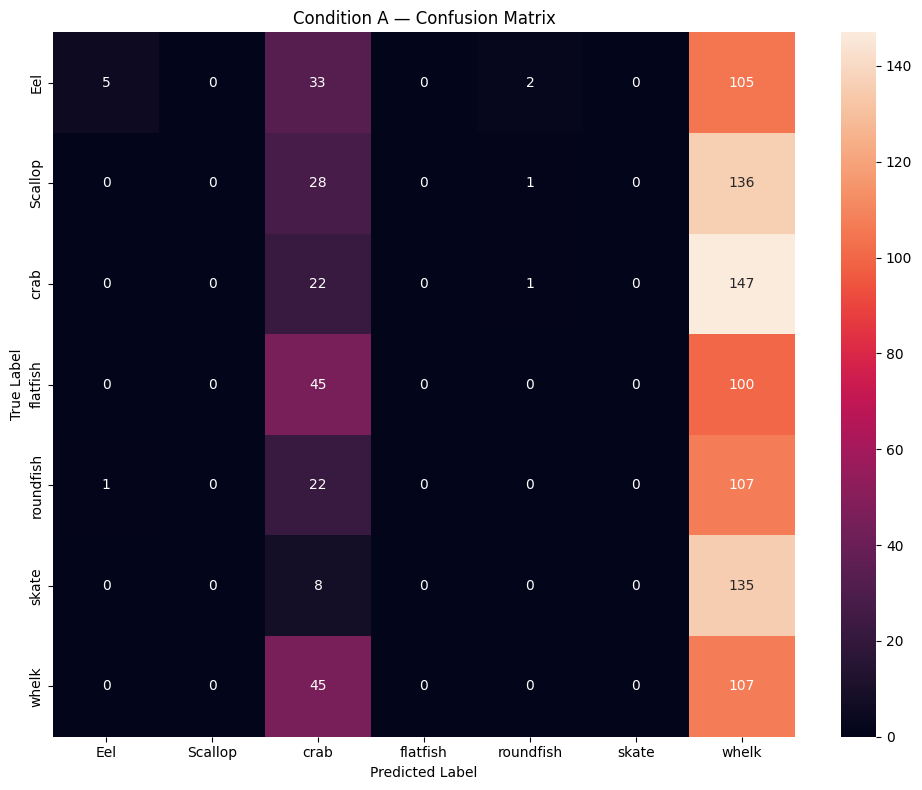

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

acc_a = evaluate_condition(model, test_loader, "Condition A")

#### Classifier Head Only: Freeze all layers except the final classification head

In [ ]:
import time
# Condition B setup — freeze backbone, train head only
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters(): #unfreeze head
    param.requires_grad = True

# head parameters
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

best_val_acc = 0.0
epochs_not_improved = 0
save_path = os.path.join(checkpoint_dir, 'best_resnet18_b.pth')
start_time_b = time.time()

In [ ]:
print(save_path)

model_checkpoints/best_resnet18_b.pth


Condition B Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Condition B Evaluating: 100%|██████████| 33/33 [00:08<00:00,  3.71it/s]


Condition B | Test Acc: 0.8905 | Time: 1.6s
              precision    recall  f1-score   support

         Eel       0.95      1.00      0.97       145
     Scallop       0.85      0.90      0.87       165
        crab       0.86      0.79      0.82       170
    flatfish       0.89      0.92      0.91       145
   roundfish       0.82      0.82      0.82       130
       skate       0.96      0.94      0.95       143
       whelk       0.90      0.86      0.88       152

    accuracy                           0.89      1050
   macro avg       0.89      0.89      0.89      1050
weighted avg       0.89      0.89      0.89      1050



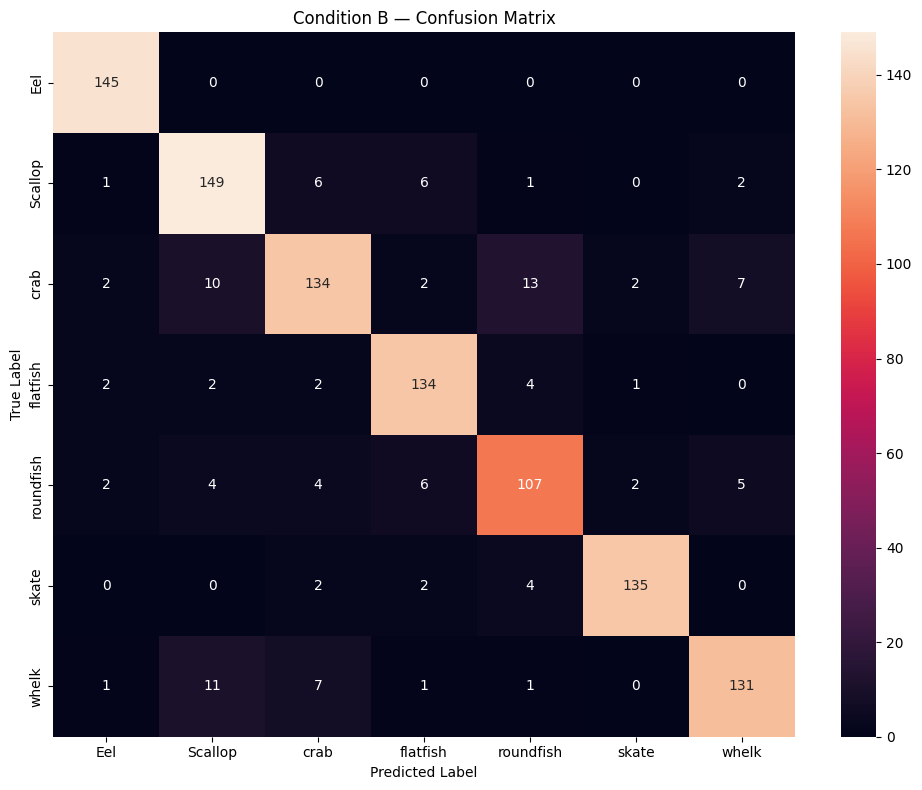

In [ ]:
# Condition B evaluate
model.load_state_dict(torch.load('model_checkpoints/best_resnet18.pth'))
acc_b = evaluate_condition(model, test_loader, "Condition B", train_time=time.time() - start_time_b)

#####

#### Full Fine-Tuning: Unfreeze all layers and fine-tune the entire network

In [ ]:
# Condition C setup — unfreeze all layers, full fine-tuning
for param in model.parameters():
    param.requires_grad = True # unfreeze all layers

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

best_val_acc = 0.0
epochs_not_improved = 0
save_path = os.path.join(checkpoint_dir, 'best_resnet18_c.pth')
start_time_c = time.time()

Condition C Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Condition C Evaluating: 100%|██████████| 33/33 [00:11<00:00,  2.98it/s]


Condition C | Test Acc: 0.8905 | Time: 28.8s
              precision    recall  f1-score   support

         Eel       0.95      1.00      0.97       145
     Scallop       0.85      0.90      0.87       165
        crab       0.86      0.79      0.82       170
    flatfish       0.89      0.92      0.91       145
   roundfish       0.82      0.82      0.82       130
       skate       0.96      0.94      0.95       143
       whelk       0.90      0.86      0.88       152

    accuracy                           0.89      1050
   macro avg       0.89      0.89      0.89      1050
weighted avg       0.89      0.89      0.89      1050



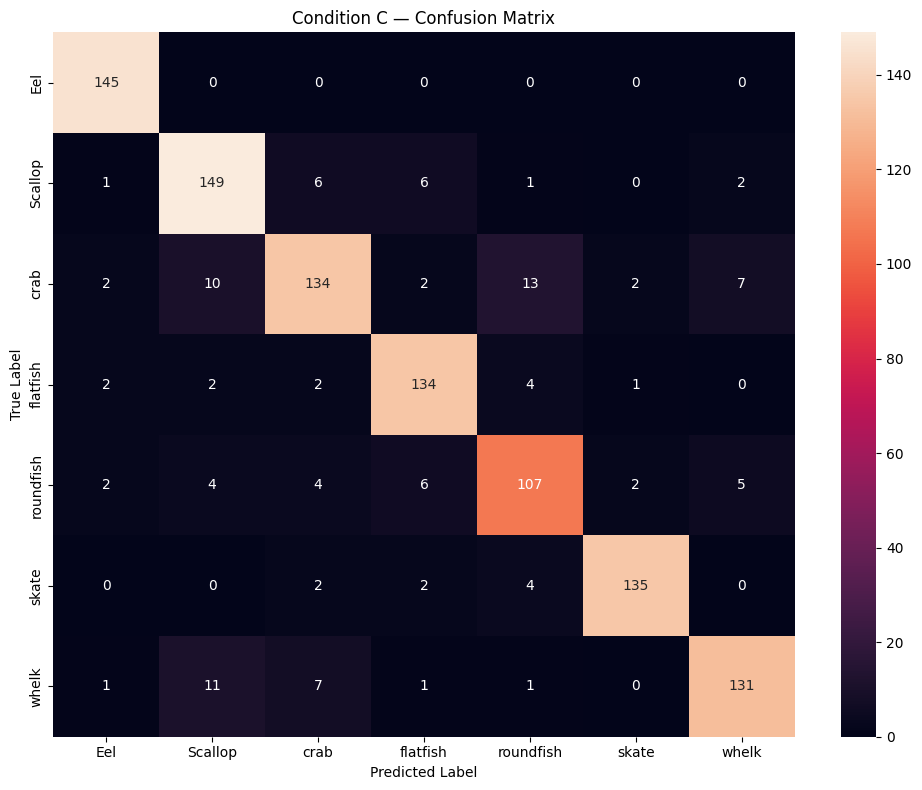

In [ ]:
# Condition C evaluate
model.load_state_dict(torch.load('model_checkpoints/best_resnet18.pth'))
acc_c = evaluate_condition(model, test_loader, "Condition C", train_time=time.time() - start_time_c)